In [ ]:
%pip install vaderSentiment --quiet


"""
YouTube Comments Sentiment Analysis
------------------------------------
Reads comments from an Excel file, performs sentiment analysis using VADER,
and saves results to a new Excel file with a summary sheet.

Requirements:
    pip install pandas openpyxl nltk vaderSentiment matplotlib seaborn
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.chart import BarChart, Reference, PieChart
import os

# ─────────────────────────────────────────────
# CONFIGURATION — Edit these to match your file
# ─────────────────────────────────────────────
INPUT_FILE   = "/content/CSK_Comments.xlsx"   # Your Excel file name
COMMENT_COL  = "Unnamed: 1"                  # Column name that holds the comment text
OUTPUT_FILE  = "sentiment_results.xlsx"  # Output file name
# ─────────────────────────────────────────────


def load_comments(filepath: str, comment_col: str) -> pd.DataFrame:
    """Load the Excel file and validate the comment column."""
    df = pd.read_excel(filepath)
    print(f"✅ Loaded {len(df):,} rows from '{filepath}'")
    print(f"   Columns found: {list(df.columns)}\n")

    if comment_col not in df.columns:
        # Try to auto-detect a comment-like column
        candidates = [c for c in df.columns if "comment" in c.lower() or "text" in c.lower()]
        if candidates:
            comment_col = candidates[0]
            print(f"⚠️  Column '{comment_col}' not found — using '{comment_col}' instead.")
        else:
            raise ValueError(
                f"Column '{comment_col}' not found. "
                f"Available columns: {list(df.columns)}"
            )

    df = df.dropna(subset=[comment_col]).copy()
    df[comment_col] = df[comment_col].astype(str).str.strip()
    df = df[df[comment_col] != ""]
    return df, comment_col


def analyze_sentiment(df: pd.DataFrame, comment_col: str) -> pd.DataFrame:
    """Run VADER sentiment on every comment and add result columns."""
    analyzer = SentimentIntensityAnalyzer()

    scores = df[comment_col].apply(lambda text: analyzer.polarity_scores(text))
    scores_df = pd.DataFrame(scores.tolist())

    df["Positive Score"]  = scores_df["pos"].round(4)
    df["Negative Score"]  = scores_df["neg"].round(4)
    df["Neutral Score"]   = scores_df["neu"].round(4)
    df["Compound Score"]  = scores_df["compound"].round(4)

    def label(compound):
        if compound >= 0.05:
            return "Positive"
        elif compound <= -0.05:
            return "Negative"
        else:
            return "Neutral"

    df["Sentiment"] = df["Compound Score"].apply(label)
    return df


def print_summary(df: pd.DataFrame) -> dict:
    """Print a text summary and return counts."""
    counts = df["Sentiment"].value_counts()
    total  = len(df)

    print("=" * 45)
    print("         SENTIMENT ANALYSIS SUMMARY")
    print("=" * 45)
    for label in ["Positive", "Neutral", "Negative"]:
        n   = counts.get(label, 0)
        pct = n / total * 100
        bar = "█" * int(pct / 2)
        print(f"  {label:<10} {n:>5} ({pct:5.1f}%)  {bar}")
    print(f"  {'Total':<10} {total:>5}")
    print("=" * 45)

    avg = df["Compound Score"].mean()
    overall = "Positive 😊" if avg >= 0.05 else "Negative 😞" if avg <= -0.05 else "Neutral 😐"
    print(f"\n  Avg Compound Score : {avg:.4f}")
    print(f"  Overall Sentiment  : {overall}\n")

    return counts.to_dict()


def save_charts(df: pd.DataFrame, counts: dict):
    """Save a bar chart and pie chart as PNG files."""
    labels  = list(counts.keys())
    values  = list(counts.values())
    colors  = {"Positive": "#4CAF50", "Negative": "#F44336", "Neutral": "#2196F3"}
    clrs    = [colors.get(l, "grey") for l in labels]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("YouTube Comments Sentiment Analysis", fontsize=14, fontweight="bold")

    # Bar chart
    axes[0].bar(labels, values, color=clrs, edgecolor="white", linewidth=1.2)
    axes[0].set_title("Comment Count by Sentiment")
    axes[0].set_ylabel("Number of Comments")
    for i, v in enumerate(values):
        axes[0].text(i, v + max(values)*0.01, str(v), ha="center", fontweight="bold")

    # Pie chart
    axes[1].pie(values, labels=labels, colors=clrs, autopct="%1.1f%%",
                startangle=140, wedgeprops=dict(edgecolor="white"))
    axes[1].set_title("Sentiment Distribution")

    plt.tight_layout()
    plt.savefig("sentiment_charts.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("📊 Charts saved → sentiment_charts.png")


def save_results(df: pd.DataFrame, counts: dict, output_file: str):
    """Write results sheet + summary sheet to Excel with basic formatting."""
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        # Sheet 1 — all comments with scores
        df.to_excel(writer, sheet_name="Sentiment Results", index=False)

        # Sheet 2 — summary table
        total = len(df)
        summary = pd.DataFrame([
            {"Sentiment": lbl,
             "Count": counts.get(lbl, 0),
             "Percentage": f"{counts.get(lbl, 0)/total*100:.1f}%"}
            for lbl in ["Positive", "Neutral", "Negative"]
        ])
        summary.to_excel(writer, sheet_name="Summary", index=False)

        # Sheet 3 — top 10 most positive & most negative
        top_pos = df.nlargest(10, "Compound Score")[[comment_col, "Compound Score", "Sentiment"]]
        top_neg = df.nsmallest(10, "Compound Score")[[comment_col, "Compound Score", "Sentiment"]]
        top_pos.to_excel(writer, sheet_name="Top Positive", index=False)
        top_neg.to_excel(writer, sheet_name="Top Negative", index=False)

    # Apply color coding to the Sentiment column
    wb = load_workbook(output_file)
    ws = wb["Sentiment Results"]

    fill_map = {
        "Positive": PatternFill("solid", fgColor="C8E6C9"),
        "Negative": PatternFill("solid", fgColor="FFCDD2"),
        "Neutral":  PatternFill("solid", fgColor="BBDEFB"),
    }

    # Find Sentiment column index
    headers = [cell.value for cell in ws[1]]
    sent_col = headers.index("Sentiment") + 1

    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        sentiment_cell = row[sent_col - 1]
        fill = fill_map.get(sentiment_cell.value)
        if fill:
            for cell in row:
                cell.fill = fill

    # Bold headers
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center")

    # Auto-width for key columns
    for col in ws.columns:
        max_len = max((len(str(c.value or "")) for c in col), default=10)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)

    wb.save(output_file)
    print(f"✅ Results saved  → {output_file}")


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    if not os.path.exists(INPUT_FILE):
        print(f"❌ File not found: '{INPUT_FILE}'")
        print("   Please set INPUT_FILE at the top of the script to your Excel file path.")
    else:
        df, comment_col  = load_comments(INPUT_FILE, COMMENT_COL)
        df               = analyze_sentiment(df, comment_col)
        counts           = print_summary(df)
        save_charts(df, counts)
        save_results(df, counts, OUTPUT_FILE)
        print("\n🎉 Done! Open 'sentiment_results.xlsx' to explore the results.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00
✅ Loaded 5,002 rows from '/content/CSK_Comments.xlsx'
   Columns found: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'U

In [ ]:
import pandas as pd

# Calculate sentiment percentages from the 'counts' dictionary
total_comments = sum(counts.values())
sentiment_percent = pd.Series({
    label: (count / total_comments * 100) for label, count in counts.items()
})

display(sentiment_percent)

,0
Positive,64.699980
Neutral,23.740718
Negative,11.559302


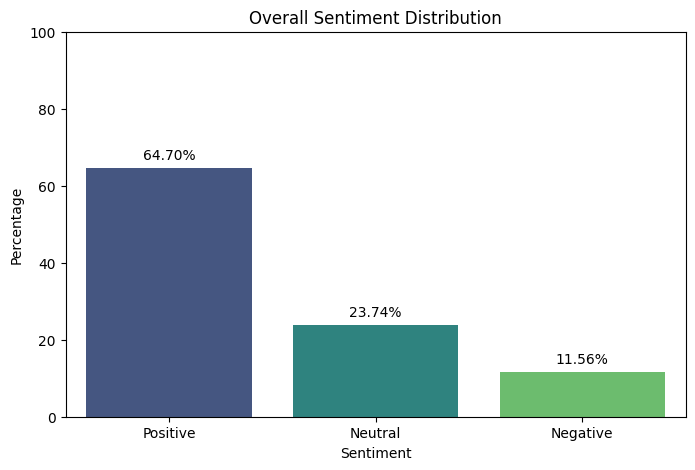

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 📊 Sentiment Percentage (Bar Chart)
# ==============================
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=sentiment_percent.index, y=sentiment_percent.values, palette='viridis', hue=sentiment_percent.index, legend=False)
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Percentage')
plt.ylim(0, 100)

# Add percentage labels on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()